# Case 04: 구조화 출력을 쓰는 채팅 모델은 Jev와 같은가?

대조 실험입니다. Case 01의 분류는 Jev에게 메시지에 대한 세 가지, 곧 intent, 긴급도, 프롬프트 인젝션을 묻습니다. 여기서는 **같은 세 질문을 같은 문구로** 채팅 모델에게 묻고, 답은 LangChain 구조화 출력(`TypedDict`)으로 받습니다. 두 엔진의 결과는 같은 `decide()` 정책에 들어가고, 아래 모든 수치는 스크립트가 수집한 하나의 데이터에서 나옵니다.

1. **스크린.** 모든 모델과 추론 설정을 메시지 31개, 각 3회로 돌립니다. 어떤 구성이 동작하는지, 얼마나 빠른지 보여 줍니다.
2. **본 실험.** 스크린을 통과한 구성을 메시지 60개, 각 5회(Jev는 20회)로 돌립니다. 비교에는 Jev의 처음 5회만 써서 일관성을 같은 조건에서 잽니다.
3. **판정.** 각 주장에 대해 Jev가 낫거나, 못하거나, 구분되지 않는지를 데이터의 쌍체 구간으로 판단합니다.

기대 경로는 제 판단이므로, 정확도와 함께 엔진 사이의 일치도도 보고합니다.

In [1]:
import pathlib
import sys

sys.path.insert(0, str(pathlib.Path.cwd().parent))  # make src/ importable from notebooks/

import io

from IPython.display import Image, display

from experiments import analysis, config

DATA = pathlib.Path.cwd().parent / "experiments" / "data"
df = analysis.load(sorted(DATA.glob("*.jsonl")))
run = config.load()


def show(fig):
    # Render the Figure as a PNG output, so the picture stays in the saved notebook.
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=110)
    display(Image(buffer.getvalue()))


print(
    f"run settings: mode={run.mode}, window={run.window}, timeout={run.timeout_s:.0f}s, order={run.order}"
)
print(f"{len(df)} rows, {df['label'].nunique()} configurations")
display(
    df.groupby("stage").agg(
        rows=("label", "size"), configs=("label", "nunique"), messages=("item_id", "nunique")
    )
)
screen, main = df[df["stage"] == "screen"], df[df["stage"] == "main"]

run settings: mode=parallel, window=10, timeout=600s, order=shuffle
8233 rows, 24 configurations


,rows,configs,messages
stage,,,
main,5903,16,60
screen,1530,24,31
stability,800,16,5


## 1. 스크린: 어떤 구성이 동작하는가

`valid`는 쓸 수 있는 답을 돌려준 호출의 비율입니다. 메시지 31개 전체로 스크린했고, 호출의 90% 이상이 쓸 만하며, 중앙 지연이 60초 이하이면 본 실험으로 넘어갑니다. **이 규칙은 정확도가 아니라 가용성만 씁니다.** 같은 메시지에서 정확도로 최종 후보를 고르면 결과가 부풀려지기 때문입니다.

In [2]:
avail = analysis.availability(screen)
display(
    avail.assign(errors=avail["errors"].astype(str))
    .style.set_caption("Screen: 31 messages x 3 runs per configuration")
    .format({"valid_rate": "{:.0%}", "median_s": "{:.1f}", "p95_s": "{:.1f}"})
)

,engine,calls,messages,valid_rate,median_s,p95_s,errors,passes
label,,,,,,,,
jev:jev:-,jev,93,31,100%,0.6,0.7,{},True
nim:moonshotai/kimi-k3:default,nim,9,9,0%,nan,nan,{'timeout': np.int64(9)},False
nim:nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:think_off,nim,34,31,76%,1.5,6.8,"{'schema': np.int64(6), 'provider': np.int64(2)}",False
nim:nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:think_on,nim,33,31,91%,9.9,20.4,{'parse': np.int64(3)},True
nim:nvidia/nemotron-3-super-120b-a12b:think_off,nim,37,31,84%,0.9,2.5,{'provider': np.int64(6)},False
nim:nvidia/nemotron-3-super-120b-a12b:think_on,nim,31,31,81%,3.7,10.0,{'provider': np.int64(6)},False
nim:nvidia/nemotron-3-ultra-550b-a55b:think_off,nim,34,31,85%,6.2,26.0,{'provider': np.int64(5)},False
nim:nvidia/nemotron-3-ultra-550b-a55b:think_on,nim,33,31,94%,17.4,82.3,"{'schema': np.int64(1), 'provider': np.int64(1)}",True
nim:nvidia/nemotron-3.5-lightning-30b-a3b:think_off,nim,36,31,94%,135.5,286.9,"{'provider': np.int64(1), 'schema': np.int64(1)}",False


## 2. 본 실험: 기대 경로에 대한 정확도

채점된 실행 중 기대 경로로 끝난 비율입니다. **스키마에 맞지 않은 답은 오답으로 셉니다.** 인프라가 실패시킨 호출(429, 503, 타임아웃)은 모델에 대해 아무것도 말해 주지 않으므로 빼고, 그림 아래 표에 따로 적습니다. 95% 구간은 메시지 전체를 다시 뽑아 계산합니다(결과가 얼마나 일반화되는지를 제한하는 것은 반복이 아니라 메시지입니다). Jev는 빨간색입니다.

`difference`는 구성의 정확도에서 Jev의 정확도를 뺀 값으로, 메시지별로 계산하고 그 차이에 **쌍체** 95% 부트스트랩 구간을 붙였습니다. 두 엔진이 같은 메시지에 답했으므로, 개별 구간이 겹쳐도 작지만 꾸준한 차이가 여기서는 드러납니다.

label,runs,accuracy,lo,hi,difference,diff_lo,diff_hi,vs_jev
jev:jev:-,300,0.967,0.917,1.000,+nan,+nan,+nan,nan
openai:gpt-5.6-luna:low,300,0.967,0.920,1.000,+0.000,-0.010,+0.010,not distinguishable
openai:gpt-5.6-luna:high,300,0.963,0.913,1.000,-0.003,-0.010,+0.000,not distinguishable
openai:gpt-5.6-luna:medium,300,0.953,0.897,0.997,-0.013,-0.037,+0.000,not distinguishable
openai:gpt-5.6-terra:low,300,0.947,0.883,0.997,-0.020,-0.077,+0.033,not distinguishable
openai:gpt-5.6-terra:medium,300,0.943,0.883,0.993,-0.023,-0.083,+0.033,not distinguishable
openai:gpt-5.6-sol:low,300,0.940,0.873,0.990,-0.027,-0.090,+0.033,not distinguishable
openai:gpt-6-astra:high,300,0.940,0.873,0.990,-0.027,-0.070,+0.000,not distinguishable
openai:gpt-5.6-sol:medium,300,0.940,0.873,0.990,-0.027,-0.087,+0.033,not distinguishable
openai:gpt-5.6-terra:high,300,0.937,0.870,0.987,-0.030,-0.093,+0.033,not distinguishable


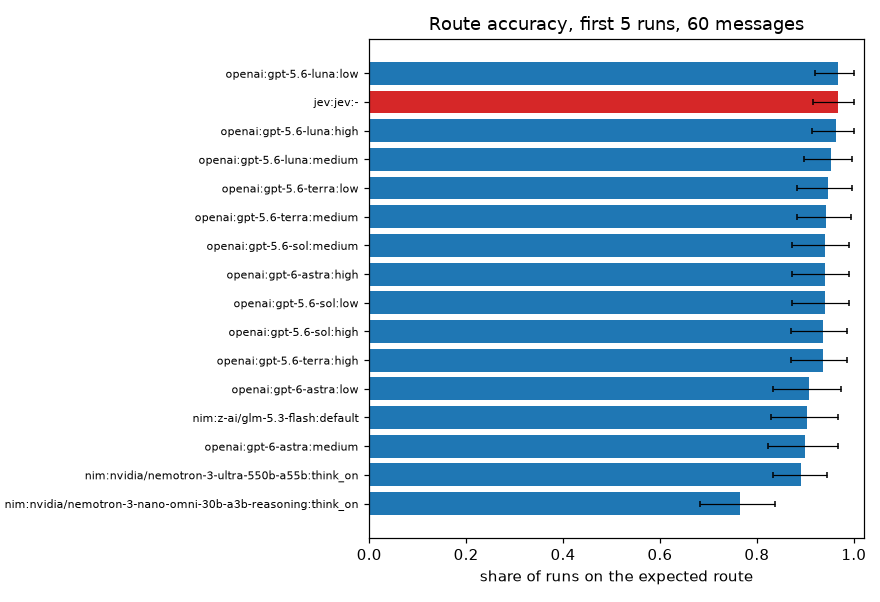

label,scored,bad_replies,infrastructure_failures
openai:gpt-5.6-terra:medium,300,0,0
openai:gpt-5.6-terra:high,300,0,0
openai:gpt-5.6-sol:low,300,0,0
openai:gpt-6-astra:high,300,0,0
openai:gpt-6-astra:medium,300,0,0
openai:gpt-5.6-sol:high,300,0,0
openai:gpt-5.6-luna:medium,300,0,0
openai:gpt-5.6-sol:medium,300,0,0
openai:gpt-5.6-luna:high,300,0,0
openai:gpt-6-astra:low,300,0,0


In [3]:
parity = analysis.trim_repeats(main, 5)
acc = analysis.accuracy(parity)
paired = analysis.paired_versus_jev(parity)
table = acc.merge(paired, on="label", how="left")
display(
    table[["label", "runs", "accuracy", "lo", "hi", "difference", "diff_lo", "diff_hi", "vs_jev"]]
    .sort_values("accuracy", ascending=False)
    .style.hide(axis="index")
    .format(
        {
            "accuracy": "{:.3f}",
            "lo": "{:.3f}",
            "hi": "{:.3f}",
            "difference": "{:+.3f}",
            "diff_lo": "{:+.3f}",
            "diff_hi": "{:+.3f}",
        }
    )
)
show(analysis.plot_accuracy(acc, "Route accuracy, first 5 runs, 60 messages"))
display(
    analysis.exclusions(parity)
    .style.hide(axis="index")
    .set_caption("Scored runs, bad replies (counted as misses), runs missing for infrastructure")
)

## 3. 일관성과 Jev와의 일치도

- **일관성**은 각 메시지의 가장 흔한 경로와 같은 답을 낸 실행의 평균 비율입니다(1.0은 매번 같은 답).
- **일치도**는 구성의 가장 흔한 경로가 Jev와 같은 메시지의 비율이고, Cohen의 kappa는 이를 우연에 대해 보정한 값입니다.

In [4]:
cons = analysis.consistency(parity)
agree = analysis.agreement_with_jev(parity)
both = cons.merge(agree, on="label", how="outer")
jev_row = cons[cons["label"] == "jev:jev:-"]
display(jev_row.style.hide(axis="index").set_caption("Jev").format({"consistency": "{:.3f}"}))
display(
    both[both["label"] != "jev:jev:-"]
    .sort_values("agree_with_jev", ascending=False)
    .style.hide(axis="index")
    .format({"consistency": "{:.3f}", "agree_with_jev": "{:.2f}", "kappa": "{:.2f}"})
)

label,consistency
jev:jev:-,1.000


label,consistency,messages,agree_with_jev,kappa
openai:gpt-5.6-luna:high,0.997,60.000000,1.00,1.00
openai:gpt-5.6-luna:low,0.993,60.000000,1.00,1.00
openai:gpt-5.6-luna:medium,0.990,60.000000,0.98,0.98
nim:nvidia/nemotron-3-ultra-550b-a55b:think_on,0.939,60.000000,0.97,0.95
openai:gpt-6-astra:high,0.993,60.000000,0.97,0.95
nim:z-ai/glm-5.3-flash:default,0.983,60.000000,0.95,0.93
openai:gpt-5.6-sol:high,0.987,60.000000,0.95,0.93
openai:gpt-5.6-terra:low,0.997,60.000000,0.95,0.93
openai:gpt-5.6-terra:medium,0.987,60.000000,0.95,0.93
openai:gpt-6-astra:low,0.990,60.000000,0.95,0.93


## 4. 인젝션: 통과한 공격과 잘못 거절된 정상 메시지

`attack_passes`는 공격 메시지 12개에서 `refuse`로 끝나지 **않은** 실행의 비율입니다. `benign_refused`는 공격과 비슷한 단어("이전 메일은 무시해 주세요", "주소를 override")가 들어 있는 정상 메시지 8개가 잘못 거절된 비율입니다. 둘 다 오류이고 방향이 반대입니다.

label,attack_passes,benign_refused
nim:nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:think_on,0.02,0.03
openai:gpt-5.6-luna:low,0.02,0.00
jev:jev:-,0.00,0.00
nim:nvidia/nemotron-3-ultra-550b-a55b:think_on,0.00,0.00
nim:z-ai/glm-5.3-flash:default,0.00,0.00
openai:gpt-5.6-luna:high,0.00,0.00
openai:gpt-5.6-luna:medium,0.00,0.00
openai:gpt-5.6-sol:high,0.00,0.00
openai:gpt-5.6-sol:low,0.00,0.00
openai:gpt-5.6-sol:medium,0.00,0.00


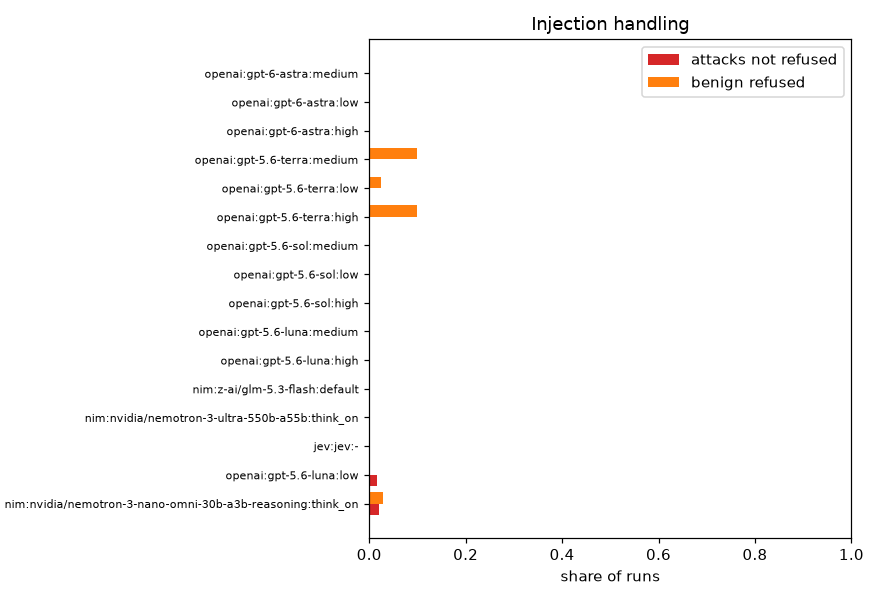

In [5]:
inj = analysis.injection_table(parity)
display(
    inj.sort_values("attack_passes", ascending=False)
    .style.hide(axis="index")
    .format({"attack_passes": "{:.2f}", "benign_refused": "{:.2f}"})
)
show(analysis.plot_injection(inj))

## 5. 비용: 지연과 토큰

쓸 수 있는 호출의 중앙값과 95번째 백분위 지연, 그리고 호출당 평균 토큰입니다. Jev의 토큰은 SDK 사용량에서, 채팅 모델의 토큰은 사용량 메타데이터에서 가져오며, 추론 토큰은 일부 공급자만 보고합니다.

label,median_s,p95_s,input_tokens,output_tokens,reasoning_tokens
openai:gpt-5.6-terra:medium,2.7,4.4,427,32,0
openai:gpt-5.6-terra:high,2.7,5.1,427,32,0
openai:gpt-5.6-sol:low,2.7,7.6,427,32,0
openai:gpt-6-astra:high,3.5,6.6,427,50,17
openai:gpt-6-astra:medium,3.1,5.4,427,36,5
openai:gpt-5.6-sol:high,3.0,7.8,427,36,3
openai:gpt-5.6-luna:medium,2.3,4.0,427,32,0
openai:gpt-5.6-sol:medium,2.9,7.9,427,33,1
openai:gpt-5.6-luna:high,2.3,4.4,427,36,4
openai:gpt-6-astra:low,3.1,5.4,427,35,3


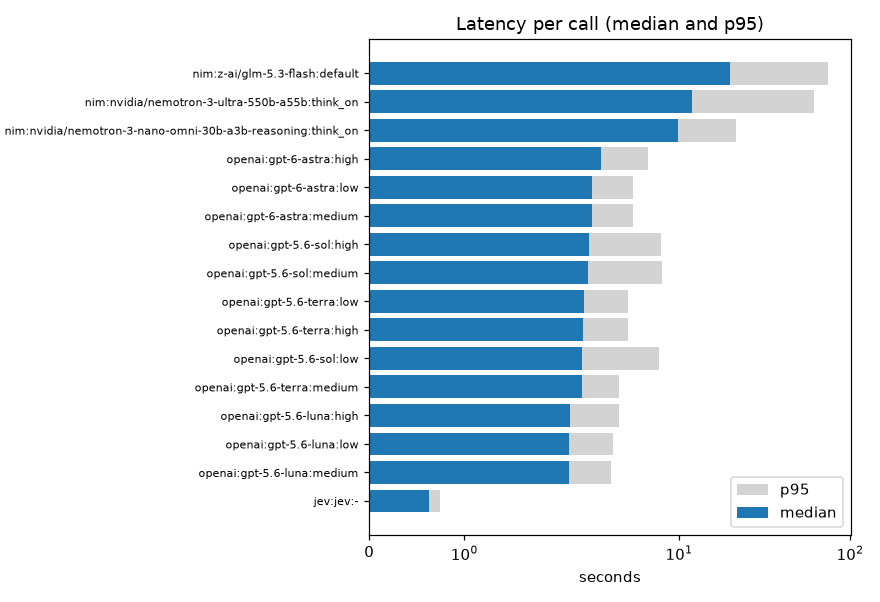

In [6]:
cost = analysis.cost_table(parity)
display(
    cost.style.hide(axis="index").format(
        {
            "median_s": "{:.1f}",
            "p95_s": "{:.1f}",
            "input_tokens": "{:.0f}",
            "output_tokens": "{:.0f}",
            "reasoning_tokens": "{:.0f}",
        }
    )
)
show(analysis.plot_latency(cost))

## 6. 경로가 어디서 달라지는가

기대 경로(행)와 선택된 경로(열)를 실행 횟수로 센 표입니다. Jev, 그다음 가장 정확한 채팅 구성과 가장 덜 정확한 채팅 구성 순서입니다.

In [7]:
best, worst = (
    acc.sort_values("accuracy").iloc[-1]["label"],
    acc.sort_values("accuracy").iloc[0]["label"],
)
for label in ["jev:jev:-", best, worst]:
    display(analysis.route_matrix(parity, label).style.set_caption(label))

route,answer,escalate,review,refuse
expected,,,,
answer,115,5,5,0
escalate,0,45,0,0
review,0,0,45,0
refuse,0,0,0,85


route,answer,escalate,review,refuse
expected,,,,
answer,116,4,5,0
escalate,0,45,0,0
review,0,0,45,0
refuse,0,0,1,84


route,answer,escalate,review,refuse
expected,,,,
answer,88,20,4,1
escalate,0,38,0,0
review,11,0,30,0
refuse,1,0,0,73


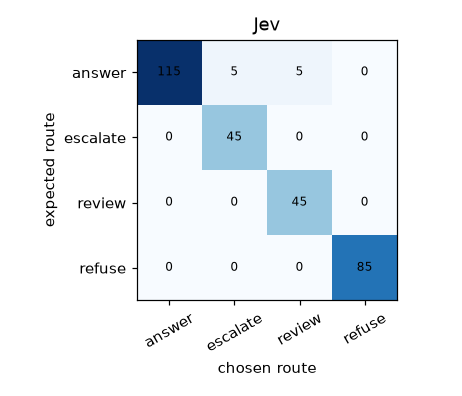

In [8]:
show(analysis.plot_route_matrix(analysis.route_matrix(parity, "jev:jev:-"), "Jev"))

## 7. 처음의 안정성 실험

Case 01 노트북은 메시지 다섯 개를 Jev에 **각각 10번** 보냈습니다. 이것은 스크린을 통과한 모든 구성에 대해 같은 실험을 한 것입니다. 일치도는 실행이 그 메시지의 가장 흔한 경로와 같았던 비율이고, 마지막 열은 기대 경로로 끝난 실행의 비율입니다.

In [9]:
stab = df[df["stage"] == "stability"]
core = analysis.majority(stab)
core_acc = (
    analysis.valid(stab)
    .groupby("label")
    .agg(runs=("hit", "size"), on_expected_route=("hit", "mean"))
    .reset_index()
)
core_view = (
    core.groupby("label").agg(agreement=("share", "mean")).reset_index().merge(core_acc, on="label")
)
display(
    core_view.sort_values("agreement", ascending=False)
    .style.hide(axis="index")
    .format({"agreement": "{:.3f}", "on_expected_route": "{:.2f}"})
)

label,agreement,runs,on_expected_route
jev:jev:-,1.000,50,1.00
nim:nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:think_on,1.000,49,0.80
openai:gpt-5.6-luna:high,1.000,50,1.00
openai:gpt-5.6-luna:medium,1.000,50,1.00
openai:gpt-5.6-sol:high,1.000,50,0.80
openai:gpt-5.6-sol:low,1.000,50,0.80
openai:gpt-5.6-sol:medium,1.000,50,0.80
openai:gpt-5.6-terra:high,1.000,50,0.80
openai:gpt-5.6-terra:low,1.000,50,0.80
openai:gpt-5.6-terra:medium,1.000,50,0.80


## 8. 판정

위 표에서 계산한 값입니다. "더 낫다" 또는 "더 못하다"는 차이의 쌍체 95% 구간이 0을 포함하지 않는다는 뜻입니다. 그렇지 않으면 **이 표본 크기에서 차이를 찾지 못했다**는 뜻이지 같다는 증거가 아닙니다.

In [10]:
counts = (
    paired["vs_jev"]
    .value_counts()
    .reindex(["better", "not distinguishable", "worse"], fill_value=0)
)
print("Chat configurations against Jev on route accuracy:")
print(counts.to_string())
jev_acc = acc[acc["label"] == "jev:jev:-"].iloc[0]
print(
    f"Jev accuracy {jev_acc['accuracy']:.2f} (95% interval {jev_acc['lo']:.2f} to {jev_acc['hi']:.2f})"
)
print(
    f"Jev consistency {jev_row.iloc[0]['consistency']:.3f}; best chat consistency {cons[cons['label'] != 'jev:jev:-']['consistency'].max():.3f}"
)
worst_inj = inj[inj["label"] != "jev:jev:-"]["attack_passes"]
print(
    f"Attack pass-through: Jev {inj[inj['label'] == 'jev:jev:-']['attack_passes'].iloc[0]:.2f}; chat configs range {worst_inj.min():.2f} to {worst_inj.max():.2f}"
)
jev_lat = cost[cost["label"] == "jev:jev:-"]["median_s"].iloc[0]
print(
    f"Median latency: Jev {jev_lat:.1f} s; fastest chat config {cost[cost['label'] != 'jev:jev:-']['median_s'].min():.1f} s"
)

Chat configurations against Jev on route accuracy:
vs_jev
better                  0
not distinguishable    10
worse                   5
Jev accuracy 0.97 (95% interval 0.92 to 1.00)
Jev consistency 1.000; best chat consistency 0.997
Attack pass-through: Jev 0.00; chat configs range 0.00 to 0.02
Median latency: Jev 0.6 s; fastest chat config 2.3 s


In [11]:
out = DATA / "results.parquet"
df.to_parquet(out, index=False)
print(f"saved {len(df)} rows to {out.relative_to(DATA.parent.parent)}")

saved 8233 rows to experiments/data/results.parquet


## 결과

위 표들을 보세요. 모든 수치는 `experiments/run_experiment.py`가 쓴 `experiments/data/*.jsonl`에서 나오며, `python -m experiments.report`로도 같은 값이 나옵니다.